In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load dataset ──────────────────────────────────────────────────────
DATASET_PATH = 'D:/Animal Dataset.csv'

encodings_to_try = ['utf-8', 'latin1', 'cp1252', 'iso-8859-1']
df = None
for enc in encodings_to_try:
    try:
        df = pd.read_csv(DATASET_PATH, encoding=enc, low_memory=False)
        print(f'✅ Loaded with encoding: {enc}')
        break
    except (UnicodeDecodeError, UnicodeError):
        continue

if df is None:
    df = pd.read_csv(DATASET_PATH, low_memory=False)
    print('✅ Loaded with default encoding')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

✅ Loaded with encoding: utf-8
Shape: 205 rows × 16 columns


,Animal,Height (cm),Weight (kg),Color,Lifespan (years),Diet,Habitat,Predators,Average Speed (km/h),Countries Found,Conservation Status,Family,Gestation Period (days),Top Speed (km/h),Social Structure,Offspring per Birth
0,Aardvark,105-130,40-65,Grey,20-30,Insectivore,"Savannas, Grasslands","Lions, Hyenas",40,Africa,Least Concern,Orycteropodidae,210-240,40,Solitary,1
1,Aardwolf,40-50,8-14,Yellow-brown,10-12,Insectivore,"Grasslands, Savannas","Lions, Leopards",24-30,Eastern and Southern Africa,Least Concern,Hyaenidae,90,40,Solitary,2-5
2,African Elephant,270-310,2700-6000,Grey,60-70,Herbivore,"Savannah, Forest","Lions, Hyenas",25,Africa,Vulnerable,Elephantidae,640-660,40,Herd-based,1
3,African Lion,80-110,120-250,Tan,10-14,Carnivore,"Grasslands, Savannas","Hyenas, Crocodiles",58,Africa,Vulnerable,Felidae,98-105,80,Group-based,2-4 (usually)
4,African Wild Dog,75-80,18-36,Multicolored,10-12,Carnivore,Savannahs,"Lions, Hyenas",56,Sub-Saharan Africa,Endangered,Canidae,70,56,Group-based,10-12


In [3]:
# ── Embedded clean_data() — 10-step robust cleaning pipeline ────────
from dataclasses import dataclass, field as dc_field
from typing import Tuple, List

@dataclass
class StepResult:
    step_number: int
    step_name: str
    executed: bool = True
    skipped: bool = False
    skip_reason: str = ""
    messages: List[str] = dc_field(default_factory=list)
    nothing_to_do: bool = False

    def add(self, msg):
        self.messages.append(msg)
    def mark_skipped(self, reason):
        self.skipped = True
        self.executed = False
        self.skip_reason = reason
    def mark_nothing_to_do(self):
        self.nothing_to_do = True
        self.messages.append("✅ No action needed")


def clean_data(df, report=True):
    import numpy as np
    import pandas as pd

    log, steps = [], []
    df = df.copy()

    # Step 1 — Normalize column names
    s1 = StepResult(1, "Normalize Column Names")
    original = list(df.columns)
    df.columns = df.columns.str.lower().str.strip().str.replace(r'\s+', '_', regex=True)
    df = df.loc[:, ~df.columns.duplicated()]
    renamed = [f"{o} → {n}" for o, n in zip(original, df.columns) if o != n]
    [s1.add(r) for r in renamed] if renamed else s1.mark_nothing_to_do()
    log.extend(renamed); steps.append(s1)

    # Step 2 — Remove duplicates
    s2 = StepResult(2, "Remove Duplicate Rows")
    before = len(df); df = df.drop_duplicates(); removed = before - len(df)
    s2.add(f"Removed {removed} duplicate rows") if removed else s2.mark_nothing_to_do()
    if removed: log.append(s2.messages[0])
    steps.append(s2)

    # Step 3 — Handle missing values
    s3 = StepResult(3, "Handle Missing Values")
    if df.isnull().any().any():
        for col in list(df.columns):
            if col not in df.columns: continue
            mr = df[col].isnull().mean()
            if mr > 0.4:
                df.drop(columns=[col], inplace=True)
                m = f"{col}: dropped (>{int(mr*100)}% missing)"
                s3.add(m); log.append(m); continue
            if mr > 0:
                if pd.api.types.is_numeric_dtype(df[col]):
                    med = df[col].median(); df[col] = df[col].fillna(med)
                    m = f"{col}: filled with median ({med:.4g})"
                else:
                    mode = df[col].mode()
                    if not mode.empty:
                        df[col] = df[col].fillna(mode[0])
                        m = f"{col}: filled with mode ('{mode[0]}')"
                    else: continue
                s3.add(m); log.append(m)
        if not s3.messages: s3.mark_nothing_to_do()
    else: s3.mark_nothing_to_do()
    steps.append(s3)

    # Step 4 — Fix data types
    s4 = StepResult(4, "Fix Data Types")
    obj_cols = df.select_dtypes(include="object").columns.tolist()
    if obj_cols:
        for col in obj_cols:
            try:
                df[col] = pd.to_numeric(df[col], errors="raise")
                s4.add(f"{col}: → numeric"); log.append(s4.messages[-1]); continue
            except: pass
            try:
                df[col] = pd.to_datetime(df[col], infer_datetime_format=True)
                s4.add(f"{col}: → datetime"); log.append(s4.messages[-1])
            except: pass
        if not s4.messages: s4.mark_nothing_to_do()
    else: s4.mark_skipped("No object columns to convert")
    steps.append(s4)

    # Step 5 — Clean text columns
    s5 = StepResult(5, "Clean Text Columns")
    txt = df.select_dtypes(include="object").columns.tolist()
    if txt:
        for col in txt:
            df[col] = df[col].astype(str).str.lower().str.strip()
            df[col] = df[col].replace({"?": np.nan, "nan": np.nan, "": np.nan})
        s5.add(f"Cleaned {len(txt)} text column(s): {txt}"); log.append(s5.messages[0])
    else: s5.mark_skipped("No text columns found")
    steps.append(s5)

    # Step 6 — Infinite values
    s6 = StepResult(6, "Handle Infinite Values")
    nc = df.select_dtypes(include=[np.number]).columns.tolist()
    if nc:
        inf_cols = [c for c in nc if np.isinf(df[c]).any()]
        if inf_cols:
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            s6.add(f"Replaced ±inf in {inf_cols}"); log.append(s6.messages[0])
        else: s6.mark_nothing_to_do()
    else: s6.mark_skipped("No numeric columns")
    steps.append(s6)

    # Step 7 — Constant columns
    s7 = StepResult(7, "Remove Constant Columns")
    cc = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
    if cc:
        df.drop(columns=cc, inplace=True)
        s7.add(f"Dropped {cc}"); log.append(s7.messages[0])
    else: s7.mark_nothing_to_do()
    steps.append(s7)

    # Step 8 — Identifier columns
    s8 = StepResult(8, "Remove Identifier Columns")
    id_cols = [c for c in df.columns if df[c].nunique(dropna=False) == len(df)]
    if id_cols:
        df.drop(columns=id_cols, inplace=True)
        s8.add(f"Dropped {id_cols}"); log.append(s8.messages[0])
    else: s8.mark_nothing_to_do()
    steps.append(s8)

    # Step 9 — IQR outlier removal
    s9 = StepResult(9, "Outlier Removal (IQR)")
    nm = df.select_dtypes(include=[np.number]).columns.tolist()
    if nm:
        total = 0
        for col in nm:
            Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
            IQR = Q3 - Q1
            if IQR == 0: continue
            b = len(df)
            df = df[(df[col] >= Q1-1.5*IQR) & (df[col] <= Q3+1.5*IQR)]
            r = b - len(df)
            if r:
                s9.add(f"{col}: removed {r} outlier(s)"); log.append(s9.messages[-1]); total += r
        if not total: s9.mark_nothing_to_do()
    else: s9.mark_skipped("No numeric columns for IQR")
    steps.append(s9)

    # Step 10 — Downcast + reset index
    s10 = StepResult(10, "Downcast Numeric Types & Reset Index")
    dc_cols = []
    for col in df.select_dtypes(include=["float64", "int64"]).columns:
        try: df[col] = pd.to_numeric(df[col], downcast="float"); dc_cols.append(col)
        except: pass
    df = df.reset_index(drop=True)
    if dc_cols: s10.add(f"Downcast {len(dc_cols)} col(s); index reset"); log.append(s10.messages[0])
    else: s10.mark_nothing_to_do()
    steps.append(s10)

    if report:
        print("\n" + "="*60)
        print("   🧹  DATA CLEANING REPORT")
        print("="*60)
        for s in steps:
            icon = "⏭ SKIP" if s.skipped else ("✅ DONE" if s.nothing_to_do else "🔧 FIX ")
            print(f"\n  Step {s.step_number:02d} | {icon} | {s.step_name}")
            if s.skipped: print(f"           ↳ {s.skip_reason}")
            elif s.nothing_to_do: print(f"           ↳ Nothing to clean")
            else: [print(f"           ↳ {m}") for m in s.messages]
        print(f"\n  📊 Final shape: {df.shape[0]} rows × {df.shape[1]} columns")
        print("="*60)

    return df, log, steps

# ── Run cleaning ──────────────────────────────────────────────────────
df_clean, cleaning_log, step_results = clean_data(df, report=True)
print(f"\n✅ Cleaning done. Shape: {df_clean.shape}")


   🧹  DATA CLEANING REPORT

  Step 01 | 🔧 FIX  | Normalize Column Names
           ↳ Animal → animal
           ↳ Height (cm) → height_(cm)
           ↳ Weight (kg) → weight_(kg)
           ↳ Color → color
           ↳ Lifespan (years) → lifespan_(years)
           ↳ Diet → diet
           ↳ Habitat → habitat
           ↳ Predators → predators
           ↳ Average Speed (km/h) → average_speed_(km/h)
           ↳ Countries Found → countries_found
           ↳ Conservation Status → conservation_status
           ↳ Family → family
           ↳ Gestation Period (days) → gestation_period_(days)
           ↳ Top Speed (km/h) → top_speed_(km/h)
           ↳ Social Structure → social_structure
           ↳ Offspring per Birth → offspring_per_birth

  Step 02 | ✅ DONE | Remove Duplicate Rows
           ↳ Nothing to clean

  Step 03 | ✅ DONE | Handle Missing Values
           ↳ Nothing to clean

  Step 04 | ✅ DONE | Fix Data Types
           ↳ Nothing to clean

  Step 05 | 🔧 FIX  | Clean Text C

In [5]:
# Compare raw vs cleaned
print(f"Raw      shape: {df.shape}")
print(f"Cleaned  shape: {df_clean.shape}")
print(f"\nCleaned Dataset — First 5 rows:")
df_clean.head()

Raw      shape: (205, 16)
Cleaned  shape: (205, 16)

Cleaned Dataset — First 5 rows:


,animal,height_(cm),weight_(kg),color,lifespan_(years),diet,habitat,predators,average_speed_(km/h),countries_found,conservation_status,family,gestation_period_(days),top_speed_(km/h),social_structure,offspring_per_birth
0,aardvark,105-130,40-65,grey,20-30,insectivore,"savannas, grasslands","lions, hyenas",40,africa,least concern,orycteropodidae,210-240,40,solitary,1
1,aardwolf,40-50,8-14,yellow-brown,10-12,insectivore,"grasslands, savannas","lions, leopards",24-30,eastern and southern africa,least concern,hyaenidae,90,40,solitary,2-5
2,african elephant,270-310,2700-6000,grey,60-70,herbivore,"savannah, forest","lions, hyenas",25,africa,vulnerable,elephantidae,640-660,40,herd-based,1
3,african lion,80-110,120-250,tan,10-14,carnivore,"grasslands, savannas","hyenas, crocodiles",58,africa,vulnerable,felidae,98-105,80,group-based,2-4 (usually)
4,african wild dog,75-80,18-36,multicolored,10-12,carnivore,savannahs,"lions, hyenas",56,sub-saharan africa,endangered,canidae,70,56,group-based,10-12


In [7]:
# Missing values after cleaning
print("Missing values per column (cleaned dataset):")
print(df_clean.isnull().sum().to_string())

Missing values per column (cleaned dataset):
animal                     0
height_(cm)                0
weight_(kg)                0
color                      0
lifespan_(years)           0
diet                       0
habitat                    0
predators                  0
average_speed_(km/h)       0
countries_found            0
conservation_status        0
family                     0
gestation_period_(days)    0
top_speed_(km/h)           0
social_structure           0
offspring_per_birth        0


In [9]:
df_clean.describe(include='all')


,animal,height_(cm),weight_(kg),color,lifespan_(years),diet,habitat,predators,average_speed_(km/h),countries_found,conservation_status,family,gestation_period_(days),top_speed_(km/h),social_structure,offspring_per_birth
count,205,205,205,205,205,205,205,205,205,205,205,205,205,205,205,205
unique,196,162,184,83,93,16,97,113,97,104,12,120,161,71,10,68
top,pink fairy armadillo,up to 30,up to 0.5,various,10-15,carnivore,rainforests,not applicable,not applicable,worldwide,least concern,canidae,not applicable,not applicable,solitary,1
freq,2,4,4,14,21,72,31,13,21,19,68,14,12,31,132,81


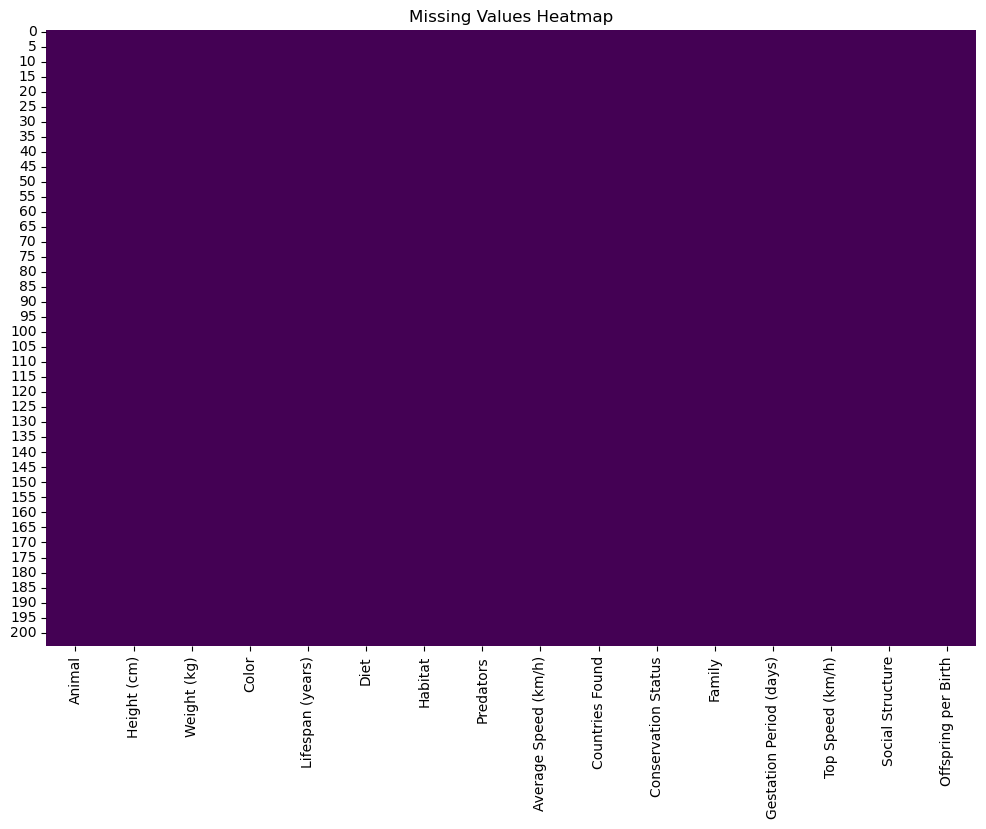

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

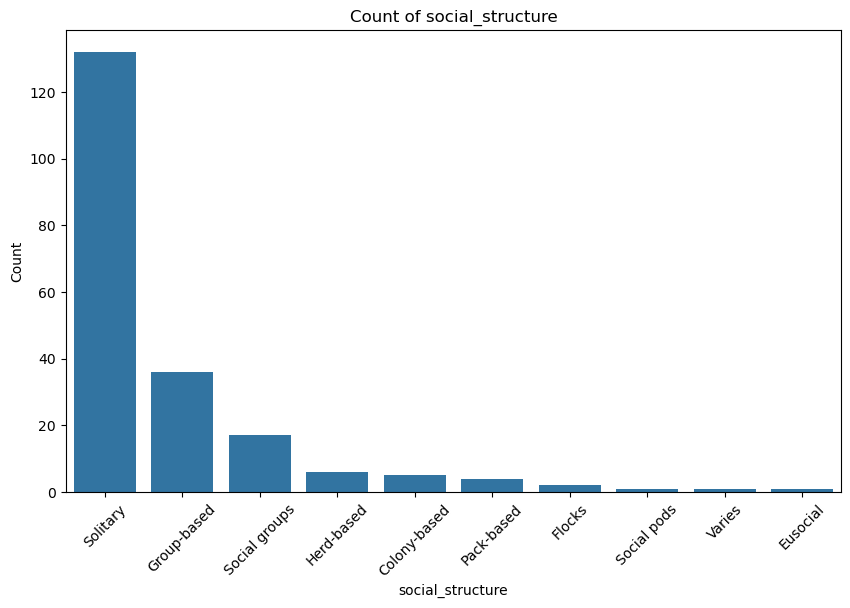

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Social Structure', order=df['Social Structure'].value_counts().index)
plt.title('Count of social_structure')
plt.xlabel('social_structure')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()